# Porto Taxi Trajectories — Exploratory Data Analysis
TDT4225 Assignment 2, Part 1

This notebook contains the exploratory data analysis (EDA) behind Part 1 of the report. The sections follow the same order as the report chapter:

**Contents**

- [1. Overview of the dataset](#section-overview)
- [2. Attribute analysis](#section-attributes)
- [3. Trajectories and missing data](#section-trajectories)
- [4. Bivariate analysis](#section-bivariate)
- [5. Multivariate analysis](#section-multivariate)
- [6. Outlier detection and data cleaning](#section-outliers)

The dataset, `porto.csv`, is about 1.9 GB, so every analysis reads it in chunks of 500,000 rows
with pandas instead of loading it into memory at once. The path to the file is read from
`PORTO_CSV_PATH` in `.env`, and generated figures are saved to `eda/figures/`.

## Setup
Imports, configuration and two helper functions used throughout the notebook:

- `poly_len` counts the GPS points in a raw `POLYLINE` string without parsing it.
- `haversine_m` returns the great-circle distance in metres between two (lon, lat) positions,
  vectorised with NumPy.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime, math, os
from pathlib import Path
from dotenv import load_dotenv

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / ".env.example").is_file():
    PROJECT_ROOT = PROJECT_ROOT.parent
load_dotenv(PROJECT_ROOT / ".env")

PATH = os.getenv("PORTO_CSV_PATH")
CHUNKSIZE = 500_000
FIGURES_DIR = PROJECT_ROOT / "eda" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)


def poly_len(s):
    if not isinstance(s, str) or s == "[]":
        return 0
    return s.count("],[") + 1


def haversine_m(lon1, lat1, lon2, lat2):
    R = 6371000
    p1, p2 = np.radians(lat1), np.radians(lat2)
    dphi = p2 - p1
    dlmb = np.radians(lon2 - lon1)
    a = np.sin(dphi / 2) ** 2 + np.cos(p1) * np.cos(p2) * np.sin(dlmb / 2) ** 2
    return 2 * R * np.arcsin(np.sqrt(a))

<a id="section-overview"></a>

## 1. Overview of the dataset

### Main pass over the data
A single pass over the whole file collects the basic statistics used in the attribute analysis:
row count, value counts for `CALL_TYPE`, `DAY_TYPE` and `MISSING_DATA`, trips per taxi,
`ORIGIN_CALL`/`ORIGIN_STAND` nulls per call type, a histogram of the number of GPS points per
trip, the time range, trips per calendar month and the number of repeated `TRIP_ID` values.

In [3]:
total_rows = 0
call_type_counts = {}
day_type_counts = {}
missing_data_counts = {}
taxi_trip_counts = {}
poly_len_hist = np.zeros(201, dtype=np.int64)
poly_len_stats = {"sum": 0, "sq_sum": 0, "min": None, "max": None, "empty": 0, "lt3": 0, "count": 0}
month_counts = {}
ts_min, ts_max = None, None
trip_id_seen = set()
dup_trip_id_rows = 0
origin_call_null_by_calltype = {}
origin_stand_null_by_calltype = {}

for i, chunk in enumerate(pd.read_csv(PATH, chunksize=CHUNKSIZE)):
    total_rows += len(chunk)

    for col, counter in [("CALL_TYPE", call_type_counts), ("DAY_TYPE", day_type_counts), ("MISSING_DATA", missing_data_counts)]:
        vc = chunk[col].value_counts(dropna=False)
        for k, v in vc.items():
            counter[str(k)] = counter.get(str(k), 0) + int(v)

    vc_taxi = chunk["TAXI_ID"].value_counts()
    for tid, v in vc_taxi.items():
        taxi_trip_counts[tid] = taxi_trip_counts.get(tid, 0) + int(v)

    for ct in chunk["CALL_TYPE"].unique():
        sub = chunk[chunk["CALL_TYPE"] == ct]
        oc = origin_call_null_by_calltype.setdefault(ct, [0, 0])
        oc[0] += int(sub["ORIGIN_CALL"].isna().sum()); oc[1] += len(sub)
        os_ = origin_stand_null_by_calltype.setdefault(ct, [0, 0])
        os_[0] += int(sub["ORIGIN_STAND"].isna().sum()); os_[1] += len(sub)

    lens = chunk["POLYLINE"].apply(poly_len)
    poly_len_stats["count"] += len(lens)
    poly_len_stats["sum"] += int(lens.sum())
    poly_len_stats["sq_sum"] += int((lens**2).sum())
    cmin, cmax = int(lens.min()), int(lens.max())
    poly_len_stats["min"] = cmin if poly_len_stats["min"] is None else min(poly_len_stats["min"], cmin)
    poly_len_stats["max"] = cmax if poly_len_stats["max"] is None else max(poly_len_stats["max"], cmax)
    poly_len_stats["empty"] += int((lens == 0).sum())
    poly_len_stats["lt3"] += int((lens < 3).sum())

    clipped = lens.clip(upper=200)
    for v in clipped.value_counts().items():
        poly_len_hist[int(v[0])] += int(v[1])

    tmin, tmax = int(chunk["TIMESTAMP"].min()), int(chunk["TIMESTAMP"].max())
    ts_min = tmin if ts_min is None else min(ts_min, tmin)
    ts_max = tmax if ts_max is None else max(ts_max, tmax)

    months = chunk["TIMESTAMP"].apply(lambda t: datetime.datetime.fromtimestamp(int(t), datetime.timezone.utc).strftime("%Y-%m"))
    for m, v in months.value_counts().items():
        month_counts[m] = month_counts.get(m, 0) + int(v)

    for tid in chunk["TRIP_ID"].tolist():
        if tid in trip_id_seen:
            dup_trip_id_rows += 1
        else:
            trip_id_seen.add(tid)

    print(f"chunk {i} processed, rows so far: {total_rows}")

mean_len = poly_len_stats["sum"] / poly_len_stats["count"]
std_len = math.sqrt(poly_len_stats["sq_sum"] / poly_len_stats["count"] - mean_len**2)

chunk 0 processed, rows so far: 500000
chunk 1 processed, rows so far: 1000000
chunk 2 processed, rows so far: 1500000
chunk 3 processed, rows so far: 1710670


### Summary
Summary of the main pass. These numbers are the basis for the overview and for several of the
subsections below (unique taxis, repeated `TRIP_ID`s, `DAY_TYPE`, `MISSING_DATA` and the
polyline length).

In [4]:
print(f"Total rows: {total_rows}")
print(f"Unique taxis: {len(taxi_trip_counts)}")
print(f"Unique trip_ids: {len(trip_id_seen)}  (duplicate rows: {dup_trip_id_rows})")
print(f"CALL_TYPE: {call_type_counts}")
print(f"DAY_TYPE: {day_type_counts}")
print(f"MISSING_DATA: {missing_data_counts}")
print(f"Polyline length: mean={mean_len:.2f}, std={std_len:.2f}, min={poly_len_stats['min']}, max={poly_len_stats['max']}")
print(f"Empty polylines: {poly_len_stats['empty']}")
print(f"Trips with <3 points (invalid): {poly_len_stats['lt3']}")
print(f"Date range: {datetime.datetime.fromtimestamp(ts_min, datetime.timezone.utc)} -> {datetime.datetime.fromtimestamp(ts_max, datetime.timezone.utc)}")
print(f"ORIGIN_CALL null by call_type: {origin_call_null_by_calltype}")
print(f"ORIGIN_STAND null by call_type: {origin_stand_null_by_calltype}")
print(f"MISSING_DATA = True: {int(missing_data_counts['True'])} trips "
      f"({int(missing_data_counts['True']) / total_rows * 100:.4f}% of all rows)")

Total rows: 1710670
Unique taxis: 448
Unique trip_ids: 1710589  (duplicate rows: 81)
CALL_TYPE: {'B': 817881, 'C': 528019, 'A': 364770}
DAY_TYPE: {'A': 1710670}
MISSING_DATA: {'False': 1710660, 'True': 10}
Polyline length: mean=48.76, std=45.65, min=0, max=3881
Empty polylines: 5901
Trips with <3 points (invalid): 43904
Date range: 2013-07-01 00:00:53+00:00 -> 2014-06-30 23:59:56+00:00
ORIGIN_CALL null by call_type: {'C': [528019, 528019], 'B': [817881, 817881], 'A': [0, 364770]}
ORIGIN_STAND null by call_type: {'C': [528019, 528019], 'B': [11302, 817881], 'A': [364770, 364770]}
MISSING_DATA = True: 10 trips (0.0006% of all rows)


<a id="section-attributes"></a>

## 2. Attribute analysis

### TAXI_ID and TRIP_ID
The summary shows 448 unique taxis, and 1,710,589 unique `TRIP_ID` values among 1,710,670 rows.
`TRIP_ID` is therefore not unique. The next cell finds the identifiers that occur more than once.

In [5]:
seen_ids = set()
dup_ids = set()
for chunk in pd.read_csv(PATH, chunksize=CHUNKSIZE, dtype={"TRIP_ID": str}):
    vc = chunk["TRIP_ID"].value_counts()
    for tid, count in vc.items():
        if tid in seen_ids or count > 1:
            dup_ids.add(tid)
        seen_ids.add(tid)
print(f"Number of TRIP_IDs that appear >1 time: {len(dup_ids)}")

Number of TRIP_IDs that appear >1 time: 80


How many times each repeated identifier occurs, and how many extra rows they give in total.

In [6]:
from collections import Counter

trip_id_counts = Counter()
for chunk in pd.read_csv(PATH, chunksize=CHUNKSIZE, dtype={"TRIP_ID": str}):
    for tid, c in chunk["TRIP_ID"].value_counts().items():
        trip_id_counts[tid] += c

dup_ids = {tid for tid, c in trip_id_counts.items() if c > 1}
group_sizes = Counter(trip_id_counts[tid] for tid in dup_ids)

print(f"TRIP_IDs occurring more than once: {len(dup_ids)}")
print(f"Group size distribution among duplicates: {dict(group_sizes)}")
print(f"Extra rows beyond one-per-ID: {sum(trip_id_counts[tid] - 1 for tid in dup_ids)}")

TRIP_IDs occurring more than once: 80
Group size distribution among duplicates: {2: 79, 3: 1}
Extra rows beyond one-per-ID: 81


The rows that share a `TRIP_ID` are compared on all nine original columns. Rows that are identical
in every column are exact duplicates and are removed during cleaning (report, Data cleaning).
The remaining rows belong to different trips. `TRIP_ID` is built from the start timestamp and
the taxi, so two different trips by the same taxi that start in the same second get the same
identifier.

In [7]:
parts = []
for chunk in pd.read_csv(PATH, chunksize=CHUNKSIZE, dtype={"TRIP_ID": str}):
    parts.append(chunk[chunk["TRIP_ID"].isin(dup_ids)])
dup_df = pd.concat(parts, ignore_index=True)   # about 161 rows

is_exact_dup = dup_df.duplicated(keep="first")  # all 9 columns, NaN == NaN
rows_to_drop = int(is_exact_dup.sum())

distinct = dup_df.drop_duplicates()
genuine_collision_groups = int((distinct.groupby("TRIP_ID").size() > 1).sum())

print(f"Total duplicate TRIP_ID groups: {dup_df['TRIP_ID'].nunique()}")
print(f"Groups with at least one genuinely different trip: {genuine_collision_groups}")
print(f"Exact-duplicate rows to drop: {rows_to_drop}")

# Inspect the rows that are dropped
print(dup_df[is_exact_dup][["TRIP_ID","CALL_TYPE","TAXI_ID","TIMESTAMP"]])
print(dup_df[is_exact_dup]["POLYLINE"].str.count(r"\],\[").add(1).tolist())

Total duplicate TRIP_ID groups: 80
Groups with at least one genuinely different trip: 78
Exact-duplicate rows to drop: 3
                 TRIP_ID CALL_TYPE   TAXI_ID   TIMESTAMP
17   1378607552620000403         C  20000403  1378607552
71   1391416612620000196         C  20000196  1391416612
116  1397172149620000454         C  20000454  1397172149
[1, 1, 6]


Number of distinct rows per repeated `TRIP_ID` after removing the exact duplicates.

In [8]:
print(distinct.groupby("TRIP_ID").size().value_counts())

2    78
1     2
Name: count, dtype: int64


### Trips per taxi
Distribution of the number of trips per taxi, and the share of all trips made by the 10 % most
and least active taxis.

Taxis: 448
Min: 1
Median: 3,732
Mean: 3,818
Max: 10,746
Std: 1,642
Top 10% of taxis (44) account for 17.2% of trips
Bottom 10% of taxis (44) account for 2.6% of trips


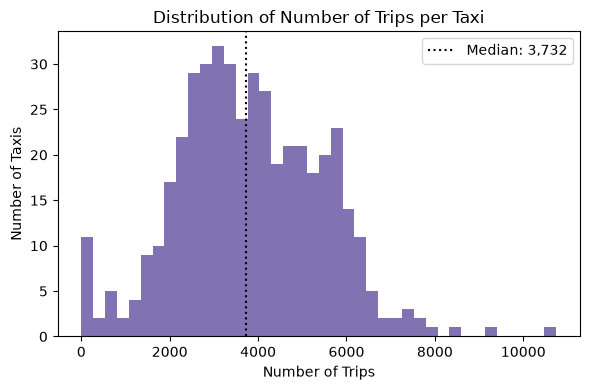

In [9]:
trip_counts_arr = np.array(list(taxi_trip_counts.values()))

print(f"Taxis: {len(trip_counts_arr)}")
print(f"Min: {trip_counts_arr.min():,}")
print(f"Median: {np.median(trip_counts_arr):,.0f}")
print(f"Mean: {trip_counts_arr.mean():,.0f}")
print(f"Max: {trip_counts_arr.max():,}")
print(f"Std: {trip_counts_arr.std():,.0f}")

k = int(len(trip_counts_arr) * 0.1)
sorted_counts = np.sort(trip_counts_arr)
print(f"Top 10% of taxis ({k}) account for {sorted_counts[-k:].sum() / trip_counts_arr.sum() * 100:.1f}% of trips")
print(f"Bottom 10% of taxis ({k}) account for {sorted_counts[:k].sum() / trip_counts_arr.sum() * 100:.1f}% of trips")

plt.figure(figsize=(6, 4))
plt.hist(trip_counts_arr, bins=40, color="#8172B2")
plt.axvline(np.median(trip_counts_arr), color="black", linestyle=":", label=f"Median: {np.median(trip_counts_arr):,.0f}")
plt.title("Distribution of Number of Trips per Taxi")
plt.xlabel("Number of Trips")
plt.ylabel("Number of Taxis")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "trips_per_taxi_hist.png", dpi=150)
plt.show()

### Trips over time
Number of trips per calendar month, with the mean and the lowest and highest month. The months
are counted in UTC, because the dataset covers exactly one year in UTC (2013-07-01 to
2014-06-30). In local time, the last 126 trips fall on 1 July 2014.

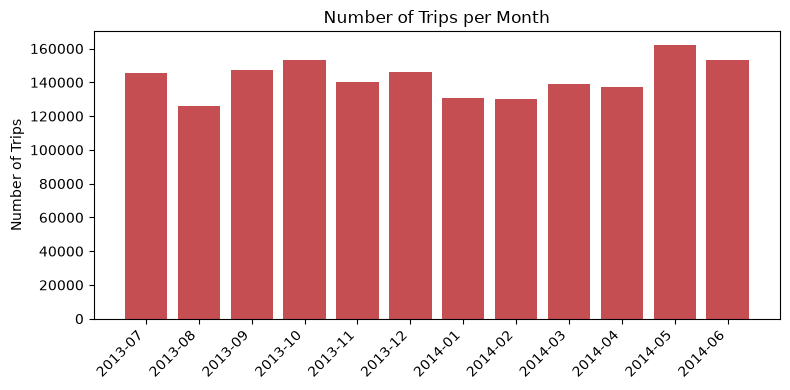

Mean per month: 142,556
Lowest:  2013-08 with 125,861 trips (-11.7% vs. mean)
Highest: 2014-05 with 162,107 trips (+13.7% vs. mean)


In [10]:
months_sorted = sorted(month_counts.keys())
plt.figure(figsize=(8,4))
plt.bar(months_sorted, [month_counts[m] for m in months_sorted], color="#C44E52")
plt.title("Number of Trips per Month")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Number of Trips")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "trips_per_month.png", dpi=150)
plt.show()

monthly = pd.Series(month_counts).sort_index()
print(f"Mean per month: {monthly.mean():,.0f}")
print(f"Lowest:  {monthly.idxmin()} with {monthly.min():,} trips ({(monthly.min() / monthly.mean() - 1) * 100:+.1f}% vs. mean)")
print(f"Highest: {monthly.idxmax()} with {monthly.max():,} trips ({(monthly.max() / monthly.mean() - 1) * 100:+.1f}% vs. mean)")

### CALL_TYPE, ORIGIN_CALL and ORIGIN_STAND
Distribution of the three call types: A (dispatch), B (taxi stand) and C (street hail).

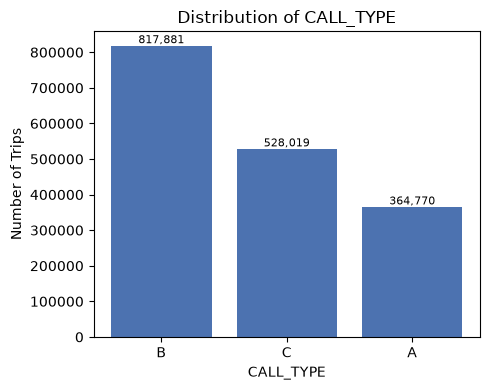

CALL_TYPE A: 364,770 trips (21.3%)
CALL_TYPE B: 817,881 trips (47.8%)
CALL_TYPE C: 528,019 trips (30.9%)


In [11]:
labels = list(call_type_counts.keys())
values = [call_type_counts[k] for k in labels]
plt.figure(figsize=(5,4))
plt.bar(labels, values, color="#4C72B0")
plt.title("Distribution of CALL_TYPE")
plt.xlabel("CALL_TYPE"); plt.ylabel("Number of Trips")
for i, v in enumerate(values):
    plt.text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=8)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "call_type_dist.png", dpi=150)
plt.show()
for k in sorted(call_type_counts):
    print(f"CALL_TYPE {k}: {call_type_counts[k]:,} trips ({call_type_counts[k] / total_rows * 100:.1f}%)")

According to the assignment, `ORIGIN_CALL` is set only for type A and `ORIGIN_STAND` only for
type B. The next cell checks this for every call type. The only deviation is a group of type B
trips without `ORIGIN_STAND`.

In [12]:
origin_call_null_by_calltype = {}
origin_stand_null_by_calltype = {}
call_type_totals = {}

for chunk in pd.read_csv(PATH, chunksize=CHUNKSIZE, usecols=["CALL_TYPE", "ORIGIN_CALL", "ORIGIN_STAND"]):
    for ct in chunk["CALL_TYPE"].unique():
        sub = chunk[chunk["CALL_TYPE"] == ct]
        call_type_totals[ct] = call_type_totals.get(ct, 0) + len(sub)

        oc = origin_call_null_by_calltype.setdefault(ct, [0, 0])
        oc[0] += int(sub["ORIGIN_CALL"].isna().sum())
        oc[1] += len(sub)

        os_ = origin_stand_null_by_calltype.setdefault(ct, [0, 0])
        os_[0] += int(sub["ORIGIN_STAND"].isna().sum())
        os_[1] += len(sub)

print("CALL_TYPE totals:", call_type_totals)
print("ORIGIN_CALL null counts by CALL_TYPE [null, total]:", origin_call_null_by_calltype)
print("ORIGIN_STAND null counts by CALL_TYPE [null, total]:", origin_stand_null_by_calltype)

# CALL_TYPE = A: ORIGIN_CALL should always be set (0 null), ORIGIN_STAND always NULL
a_call_null, a_call_total = origin_call_null_by_calltype["A"]
a_stand_null, a_stand_total = origin_stand_null_by_calltype["A"]
assert a_call_null == 0, "Expected ORIGIN_CALL always set for CALL_TYPE=A"
assert a_stand_null == a_stand_total, "Expected ORIGIN_STAND always NULL for CALL_TYPE=A"
print(f"CALL_TYPE=A: ORIGIN_CALL set for all {a_call_total} trips, ORIGIN_STAND NULL for all of them.")

# CALL_TYPE = C: both should always be NULL
c_call_null, c_call_total = origin_call_null_by_calltype["C"]
c_stand_null, c_stand_total = origin_stand_null_by_calltype["C"]
assert c_call_null == c_call_total, "Expected ORIGIN_CALL always NULL for CALL_TYPE=C"
assert c_stand_null == c_stand_total, "Expected ORIGIN_STAND always NULL for CALL_TYPE=C"
print(f"CALL_TYPE=C: both fields NULL for all {c_call_total} trips.")

# CALL_TYPE = B: ORIGIN_CALL always NULL, ORIGIN_STAND set for most but not all
b_call_null, b_call_total = origin_call_null_by_calltype["B"]
b_stand_null, b_stand_total = origin_stand_null_by_calltype["B"]
assert b_call_null == b_call_total, "Expected ORIGIN_CALL always NULL for CALL_TYPE=B"
b_stand_set = b_stand_total - b_stand_null
print(f"CALL_TYPE=B: ORIGIN_CALL NULL for all {b_call_total} trips.")
print(f"CALL_TYPE=B: ORIGIN_STAND set for {b_stand_set} / {b_stand_total} trips "
      f"({100*b_stand_set/b_stand_total:.1f}%), missing for {b_stand_null} "
      f"({100*b_stand_null/b_stand_total:.1f}%).")

CALL_TYPE totals: {'C': 528019, 'B': 817881, 'A': 364770}
ORIGIN_CALL null counts by CALL_TYPE [null, total]: {'C': [528019, 528019], 'B': [817881, 817881], 'A': [0, 364770]}
ORIGIN_STAND null counts by CALL_TYPE [null, total]: {'C': [528019, 528019], 'B': [11302, 817881], 'A': [364770, 364770]}
CALL_TYPE=A: ORIGIN_CALL set for all 364770 trips, ORIGIN_STAND NULL for all of them.
CALL_TYPE=C: both fields NULL for all 528019 trips.
CALL_TYPE=B: ORIGIN_CALL NULL for all 817881 trips.
CALL_TYPE=B: ORIGIN_STAND set for 806579 / 817881 trips (98.6%), missing for 11302 (1.4%).


### DAY_TYPE
The assignment describes three possible values: A (normal day), B (holiday) and C (day before
holiday). This cell checks which values actually occur. All three are shown in the bar chart so
that the empty ones are visible.

DAY_TYPE value counts: {'A': 1710670}
Number of distinct DAY_TYPE values: 1
Total rows: 1710670
All rows have DAY_TYPE = 'A'


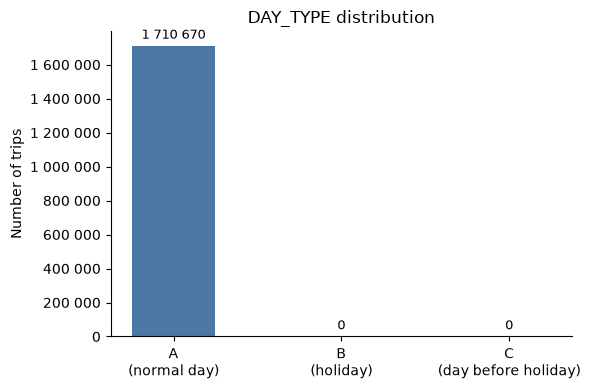

In [13]:
day_type_counts = {}

for chunk in pd.read_csv(PATH, chunksize=CHUNKSIZE, usecols=["DAY_TYPE"]):
    vc = chunk["DAY_TYPE"].value_counts(dropna=False)
    for k, v in vc.items():
        day_type_counts[str(k)] = day_type_counts.get(str(k), 0) + int(v)

print(f"DAY_TYPE value counts: {day_type_counts}")
print(f"Number of distinct DAY_TYPE values: {len(day_type_counts)}")
print(f"Total rows: {sum(day_type_counts.values())}")
assert len(day_type_counts) == 1, "DAY_TYPE is not constant!"
print(f"All rows have DAY_TYPE = '{list(day_type_counts.keys())[0]}'")

# Bar chart: include all three documented values so the empty ones are visible
labels = ["A\n(normal day)", "B\n(holiday)", "C\n(day before holiday)"]
counts = [day_type_counts.get(k, 0) for k in ["A", "B", "C"]]

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(labels, counts, color="#4C78A8", width=0.5)
ax.set_ylabel("Number of trips")
ax.set_title("DAY_TYPE distribution")
ax.yaxis.set_major_formatter(lambda x, _: f"{int(x):,}".replace(",", " "))
ax.spines[["top", "right"]].set_visible(False)

for bar, c in zip(bars, counts):
    ax.annotate(f"{c:,}".replace(",", " "),
                (bar.get_x() + bar.get_width() / 2, c),
                ha="center", va="bottom", fontsize=9,
                xytext=(0, 3), textcoords="offset points")

plt.tight_layout()
plt.show()

<a id="section-trajectories"></a>

## 3. Trajectories and missing data
GPS points are sampled every 15 seconds, so a trip with $N$ points has the duration
$(N-1) \times 15$ seconds.

### POLYLINE length
Histogram of the number of GPS points per trip for 0–199 points, built from the histogram
collected in the main pass. Trips with 200 or more points are counted but not shown.

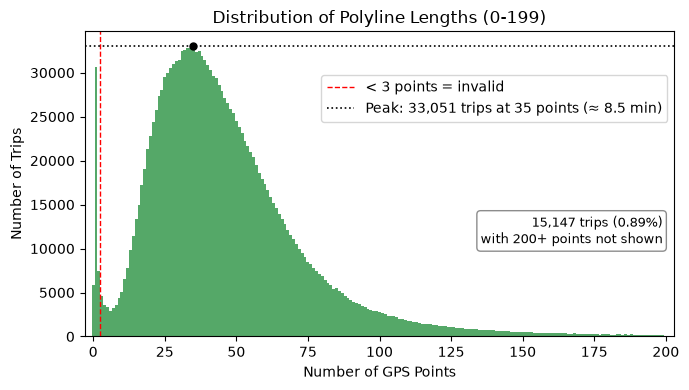

Trips with 200+ points (not shown): 15,147 (0.89%)
Most common length (3-199 points): 35 points in 33,051 trips (≈ 8.5 min)


In [14]:
# Peak: ignore 0-2 points (the spike of invalid trips)
mode_pts = int(np.argmax(poly_len_hist[3:200]) + 3)
mode_count = int(poly_len_hist[mode_pts])
mode_min = (mode_pts - 1) * 15 / 60

long_trips = int(poly_len_hist[200])   # trips with 200+ points (not shown)

plt.figure(figsize=(7, 4))
plt.bar(range(200), poly_len_hist[:200], width=1.0, color="#55A868")
plt.axvline(2.5, color="red", linestyle="--", linewidth=1, label="< 3 points = invalid")
plt.axhline(mode_count, color="black", linestyle=":", linewidth=1.2,
            label=f"Peak: {mode_count:,} trips at {mode_pts} points (≈ {mode_min:.1f} min)")
plt.plot(mode_pts, mode_count, "o", color="black", markersize=5)

plt.title("Distribution of Polyline Lengths (0-199)")
plt.xlabel("Number of GPS Points")
plt.ylabel("Number of Trips")
plt.text(0.98, 0.40,
         f"{long_trips:,} trips ({long_trips/poly_len_stats['count']*100:.2f}%)\n"
         f"with 200+ points not shown",
         transform=plt.gca().transAxes, ha="right", va="top", fontsize=9,
         bbox=dict(boxstyle="round", facecolor="white", edgecolor="gray", alpha=0.9))
plt.xlim(-3, 203)
plt.legend(loc="upper right", bbox_to_anchor=(1, 0.88))
plt.tight_layout()
plt.savefig(FIGURES_DIR / "polyline_length_hist.png", dpi=150)
plt.show()

print(f"Trips with 200+ points (not shown): {long_trips:,} ({long_trips/poly_len_stats['count']*100:.2f}%)")
print(f"Most common length (3-199 points): {mode_pts} points in {mode_count:,} trips (≈ {mode_min:.1f} min)")

Mean and standard deviation of the number of points, for all trips and for trips with
3–199 points.

In [15]:
pts = np.arange(3, 200)
cnt = poly_len_hist[3:200]
mean_mid = (pts * cnt).sum() / cnt.sum()
std_mid = np.sqrt((pts**2 * cnt).sum() / cnt.sum() - mean_mid**2)

print(f"Trips with 3-199 points: {cnt.sum():,}")
print(f"Mean: {mean_mid:.1f} points = {(mean_mid-1)*15/60:.1f} min")
print(f"Std:  {std_mid:.1f} points = {std_mid*15/60:.1f} min")
print(f"Overall mean: {poly_len_stats['sum']/poly_len_stats['count']:.1f} points "
      f"= {(poly_len_stats['sum']/poly_len_stats['count']-1)*15/60:.1f} min")

Trips with 3-199 points: 1,651,619
Mean: 47.2 points = 11.6 min
Std:  27.0 points = 6.7 min
Overall mean: 48.8 points = 11.9 min


### Very short trips
Following the assignment, a trip with fewer than 3 GPS points is invalid. The histogram has a
clear spike at exactly 1 point (30,609 trips, against 5,901 with 0 points and 7,394 with
2 points). The spike is not explained by the `MISSING_DATA` flag, it is over-represented for
`CALL_TYPE = C` (street hail), and it is concentrated on a single taxi.

The most likely explanation is a combination of (a) the taximeter being started without an
actual passenger, and (b) a systematic GPS/taximeter fault in at least one vehicle that logs a
single point before the connection drops. Both point to noise in the data collection rather than
real short trips. The trips are flagged as invalid, not deleted (see section 6).

First, the call type of the 1-point trips compared with all trips.

In [16]:
len1_by_calltype = {}

for chunk in pd.read_csv(PATH, chunksize=CHUNKSIZE, usecols=["CALL_TYPE", "POLYLINE"]):
    lens = chunk["POLYLINE"].apply(poly_len)
    for ct, v in chunk.loc[lens == 1, "CALL_TYPE"].value_counts().items():
        len1_by_calltype[ct] = len1_by_calltype.get(ct, 0) + int(v)

n_len1 = sum(len1_by_calltype.values())
print(f"Trips with exactly 1 point: {n_len1:,}")
for ct in sorted(len1_by_calltype):
    print(f"  CALL_TYPE {ct}: {len1_by_calltype[ct]:,} ({len1_by_calltype[ct] / n_len1 * 100:.1f}%), "
          f"vs. {call_type_counts[ct] / total_rows * 100:.1f}% of all trips")

Trips with exactly 1 point: 30,609
  CALL_TYPE A: 1,628 (5.3%), vs. 21.3% of all trips
  CALL_TYPE B: 7,167 (23.4%), vs. 47.8% of all trips
  CALL_TYPE C: 21,814 (71.3%), vs. 30.9% of all trips


Number of invalid trips (fewer than 3 points) in total and per taxi. Taxi 20000080 alone
accounts for far more of them than any other taxi.

In [17]:
MIN_POINTS = 3  # invalid trip threshold from the assignment text

invalid_by_taxi = {}
lens_len1 = {}
total = 0
invalid_count = 0
len1_count = 0

for chunk in pd.read_csv(PATH, chunksize=CHUNKSIZE):
    lens = chunk["POLYLINE"].apply(poly_len)
    total += len(chunk)

    mask_invalid = lens < MIN_POINTS
    invalid_count += int(mask_invalid.sum())
    vc_invalid = chunk.loc[mask_invalid, "TAXI_ID"].value_counts()
    for tid, v in vc_invalid.items():
        invalid_by_taxi[tid] = invalid_by_taxi.get(tid, 0) + int(v)

    mask_len1 = lens == 1
    len1_count += int(mask_len1.sum())
    vc1 = chunk.loc[mask_len1, "TAXI_ID"].value_counts()
    for tid, v in vc1.items():
        lens_len1[tid] = lens_len1.get(tid, 0) + int(v)

print(f"Total trips: {total}")
print(f"Trips with < {MIN_POINTS} points (invalid): {invalid_count} ({100*invalid_count/total:.2f}%)")
print(f"Trips with >= {MIN_POINTS} points: {total - invalid_count} ({100*(total-invalid_count)/total:.2f}%)")

top_taxis_invalid = sorted(invalid_by_taxi.items(), key=lambda x: -x[1])[:10]
print(f"\nTop 10 taxis contributing to <{MIN_POINTS}-point trips:")
for tid, cnt in top_taxis_invalid:
    print(f"  taxi {tid}: {cnt} trips")

top_taxi_id, top_taxi_count = top_taxis_invalid[0]
print(f"\nTaxi {top_taxi_id} alone: {top_taxi_count} trips "
      f"({100*top_taxi_count/invalid_count:.1f}% of all <{MIN_POINTS}-point trips)")

top_taxis_len1 = sorted(lens_len1.items(), key=lambda x: -x[1])[:5]
print(f"\nSame taxi's share of exact 1-point trips: "
      f"{lens_len1.get(top_taxi_id,0)} / {len1_count} "
      f"({100*lens_len1.get(top_taxi_id,0)/len1_count:.1f}%)")

Total trips: 1710670
Trips with < 3 points (invalid): 43904 (2.57%)
Trips with >= 3 points: 1666766 (97.43%)

Top 10 taxis contributing to <3-point trips:
  taxi 20000080: 6535 trips
  taxi 20000066: 2497 trips
  taxi 20000403: 1722 trips
  taxi 20000663: 995 trips
  taxi 20000196: 696 trips
  taxi 20000364: 551 trips
  taxi 20000286: 521 trips
  taxi 20000099: 512 trips
  taxi 20000167: 510 trips
  taxi 20000129: 508 trips

Taxi 20000080 alone: 6535 trips (14.9% of all <3-point trips)

Same taxi's share of exact 1-point trips: 5301 / 30609 (17.3%)


Share of each taxi's own trips that have fewer than 3 points: the outlier taxi against the rest
of the fleet. A share of about 61 % against about 2 % is consistent with a single faulty unit.

Taxi 20000080 share of its own trips that are short: 60.81%
Rest of fleet average share: 2.20%


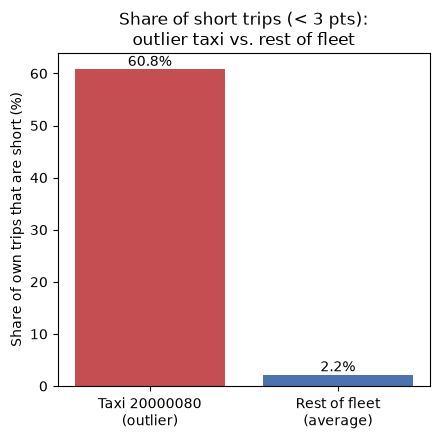

In [18]:
MIN_POINTS = 3  # invalid trip threshold from the assignment text

total_by_taxi = {}
short_by_taxi = {}

for chunk in pd.read_csv(PATH, chunksize=CHUNKSIZE):
    lens = chunk["POLYLINE"].apply(poly_len)
    vc_total = chunk["TAXI_ID"].value_counts()
    for tid, v in vc_total.items():
        total_by_taxi[tid] = total_by_taxi.get(tid, 0) + int(v)
    vc_short = chunk.loc[lens < MIN_POINTS, "TAXI_ID"].value_counts()
    for tid, v in vc_short.items():
        short_by_taxi[tid] = short_by_taxi.get(tid, 0) + int(v)

shares = {tid: short_by_taxi.get(tid, 0) / total_by_taxi[tid] for tid in total_by_taxi}

outlier_taxi_id, outlier_short_count = max(short_by_taxi.items(), key=lambda x: x[1])
outlier_share = shares[outlier_taxi_id]

rest_short = sum(short_by_taxi.values()) - outlier_short_count
rest_total = sum(total_by_taxi.values()) - total_by_taxi[outlier_taxi_id]
rest_share = rest_short / rest_total

print(f"Taxi {outlier_taxi_id} share of its own trips that are short: {outlier_share*100:.2f}%")
print(f"Rest of fleet average share: {rest_share*100:.2f}%")

plt.figure(figsize=(4.5,4.5))
labels = [f"Taxi {outlier_taxi_id}\n(outlier)", "Rest of fleet\n(average)"]
values = [outlier_share * 100, rest_share * 100]
bars = plt.bar(labels, values, color=["#C44E52", "#4C72B0"])
plt.ylabel("Share of own trips that are short (%)")
plt.title(f"Share of short trips (< {MIN_POINTS} pts):\noutlier taxi vs. rest of fleet")
for b, v in zip(bars, values):
    plt.text(b.get_x()+b.get_width()/2, v, f"{v:.1f}%", ha="center", va="bottom", fontsize=10)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "outlier_taxi_share_comparison.png", dpi=150)
plt.show()

### Trip distance and average speed
Trips with fewer than 3 points (under 30 seconds) are left out, since neither distance nor
speed is meaningful for them. The distance is the sum of the Haversine distances between
consecutive points, i.e. the length of the path driven, and the average speed is the distance
divided by the duration. The histograms are cut at the 99th percentile for distance and at
100 km/h for speed.

chunk 0 done
chunk 1 done
chunk 2 done
chunk 3 done
Valid trips analysed: 1,666,766
Distance km: median=4.027, mean=5.650, p99=24.354, max=1229.3
Avg speed km/h: median=24.0, mean=27.5, p99=73.8, max=28835.2
Speed > 120 km/h: 2,127 (0.13% of valid trips)
Speed > 150 km/h: 1,209
Speed > 200 km/h: 624
Speed < 1 km/h with >= 20 points: 2,089
Distance == 0 km: 15


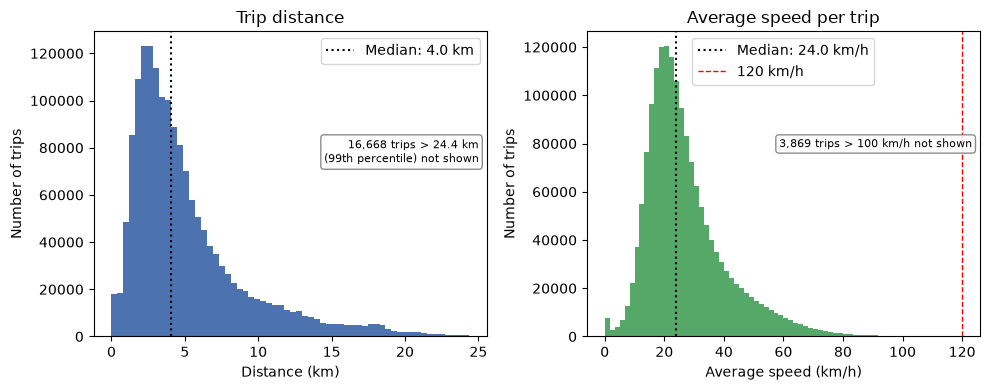

In [19]:
MIN_VALID = 3
MANY_POINTS = 20

dist_parts, speed_parts, npts_parts = [], [], []

for i, chunk in enumerate(pd.read_csv(PATH, chunksize=CHUNKSIZE, usecols=["POLYLINE"])):
    d, s, n_list = [], [], []
    for poly in chunk["POLYLINE"]:
        if poly_len(poly) < MIN_VALID:
            continue
        pts = np.fromstring(poly.replace("[", "").replace("]", ""), sep=",").reshape(-1, 2)
        n = len(pts)
        dist_km = haversine_m(pts[:-1, 0], pts[:-1, 1], pts[1:, 0], pts[1:, 1]).sum() / 1000
        dur_h = (n - 1) * 15 / 3600
        d.append(dist_km)
        s.append(dist_km / dur_h)
        n_list.append(n)
    dist_parts.append(np.array(d, dtype=np.float32))
    speed_parts.append(np.array(s, dtype=np.float32))
    npts_parts.append(np.array(n_list, dtype=np.int32))
    print(f"chunk {i} done")

dist = np.concatenate(dist_parts)
speed = np.concatenate(speed_parts)
npts = np.concatenate(npts_parts)

p99_dist = np.percentile(dist, 99)
print(f"Valid trips analysed: {len(dist):,}")
print(f"Distance km: median={np.median(dist):.3f}, mean={dist.mean():.3f}, p99={p99_dist:.3f}, max={dist.max():.1f}")
print(f"Avg speed km/h: median={np.median(speed):.1f}, mean={speed.mean():.1f}, p99={np.percentile(speed, 99):.1f}, max={speed.max():.1f}")
print(f"Speed > 120 km/h: {(speed > 120).sum():,} ({(speed > 120).mean() * 100:.2f}% of valid trips)")
print(f"Speed > 150 km/h: {(speed > 150).sum():,}")
print(f"Speed > 200 km/h: {(speed > 200).sum():,}")
print(f"Speed < 1 km/h with >= {MANY_POINTS} points: {((speed < 1) & (npts >= MANY_POINTS)).sum():,}")
print(f"Distance == 0 km: {(dist == 0).sum():,}")

speed_clip = 100
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

ax[0].hist(dist[dist <= p99_dist], bins=60, color="#4C72B0")
ax[0].axvline(np.median(dist), color="black", linestyle=":", label=f"Median: {np.median(dist):.1f} km")
ax[0].set_title("Trip distance")
ax[0].set_xlabel("Distance (km)")
ax[0].set_ylabel("Number of trips")
ax[0].text(0.98, 0.65, f"{(dist > p99_dist).sum():,} trips > {p99_dist:.1f} km\n(99th percentile) not shown",
           transform=ax[0].transAxes, ha="right", va="top", fontsize=8,
           bbox=dict(boxstyle="round", facecolor="white", edgecolor="gray", alpha=0.9))
ax[0].legend()

ax[1].hist(speed[speed <= speed_clip], bins=60, color="#55A868")
ax[1].axvline(np.median(speed), color="black", linestyle=":", label=f"Median: {np.median(speed):.1f} km/h")
ax[1].axvline(120, color="red", linestyle="--", linewidth=1, label="120 km/h")
ax[1].set_title("Average speed per trip")
ax[1].set_xlabel("Average speed (km/h)")
ax[1].set_ylabel("Number of trips")
ax[1].text(0.98, 0.65, f"{(speed > speed_clip).sum():,} trips > {speed_clip} km/h not shown",
           transform=ax[1].transAxes, ha="right", va="top", fontsize=8,
           bbox=dict(boxstyle="round", facecolor="white", edgecolor="gray", alpha=0.9))
ax[1].legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / "distance_speed_hist.png", dpi=150)
plt.show()

### Spatial analysis of GPS points
One pass over all GPS points collects what is needed for the spatial analysis: the coordinate
range, the distance from every point to Porto City Hall, jumps between consecutive points, and
the start point of every trip.

In [20]:
CH_LON, CH_LAT = -8.62911, 41.15794       # Porto City Hall (from the assignment)
FAR_KM = [20, 50, 100, 300]
MAP_THRESHOLD_KM = 300
JUMP_M = 150 / 3.6 * 15                    # 625 m per 15 s = 150 km/h

total_points = 0
far_points = {k: 0 for k in FAR_KM}
far_trips = {k: 0 for k in FAR_KM}
zero_points = 0
lon_min = lat_min = np.inf
lon_max = lat_max = -np.inf
jump_segments = 0
jump_trips = 0
jumps_by_taxi = {}
starts_parts = []
far_point_rows = []
source_row_offset = 0

for i, chunk in enumerate(pd.read_csv(PATH, chunksize=CHUNKSIZE, usecols=["TAXI_ID", "POLYLINE"])):
    starts = []
    for local_row, (taxi, poly) in enumerate(zip(chunk["TAXI_ID"], chunk["POLYLINE"])):
        if poly_len(poly) == 0:
            continue
        pts = np.fromstring(poly.replace("[", "").replace("]", ""), sep=",").reshape(-1, 2)
        n = len(pts)
        total_points += n
        starts.append(pts[0])

        lon_min = min(lon_min, pts[:, 0].min()); lon_max = max(lon_max, pts[:, 0].max())
        lat_min = min(lat_min, pts[:, 1].min()); lat_max = max(lat_max, pts[:, 1].max())
        zero_points += int(((pts[:, 0] == 0) & (pts[:, 1] == 0)).sum())

        d_km = haversine_m(pts[:, 0], pts[:, 1], CH_LON, CH_LAT) / 1000
        for k in FAR_KM:
            c = int((d_km > k).sum())
            far_points[k] += c
            far_trips[k] += int(c > 0)

        # Keep every qualifying point for the map, with its source row and sequence.
        for seq in np.flatnonzero(d_km > MAP_THRESHOLD_KM):
            far_point_rows.append({
                "source_row": source_row_offset + local_row,
                "seq": int(seq),
                "lon": float(pts[seq, 0]),
                "lat": float(pts[seq, 1]),
                "distance_km": float(d_km[seq]),
            })

        if n >= 2:
            steps = haversine_m(pts[:-1, 0], pts[:-1, 1], pts[1:, 0], pts[1:, 1])
            j = int((steps > JUMP_M).sum())
            if j > 0:
                jump_segments += j
                jump_trips += 1
                jumps_by_taxi[taxi] = jumps_by_taxi.get(taxi, 0) + j
    source_row_offset += len(chunk)
    starts_parts.append(np.array(starts))
    print(f"chunk {i} done")

starts = np.concatenate(starts_parts)
far_point_df = pd.DataFrame(far_point_rows)

print(f"Total GPS points: {total_points:,}")
print(f"Lon range: {lon_min:.5f} to {lon_max:.5f}, lat range: {lat_min:.5f} to {lat_max:.5f}")
print(f"Points exactly (0,0): {zero_points:,}")

chunk 0 done
chunk 1 done
chunk 2 done
chunk 3 done
Total GPS points: 83,409,386
Lon range: -36.91378 to 52.90080, lat range: 31.99211 to 51.03712
Points exactly (0,0): 0


#### Distance from the city centre
Number of points, and number of trips with at least one such point, further than 20, 50, 100
and 300 km from Porto City Hall.

In [21]:
for k in FAR_KM:
    print(f"> {k} km from City Hall: {far_points[k]:,} points ({far_points[k]/total_points*100:.4f}%) in {far_trips[k]:,} trips")

> 20 km from City Hall: 1,172,630 points (1.4059%) in 7,776 trips
> 50 km from City Hall: 456,161 points (0.5469%) in 1,810 trips
> 100 km from City Hall: 168,435 points (0.2019%) in 625 trips
> 300 km from City Hall: 735 points (0.0009%) in 29 trips


#### Map of GPS points more than 300 km from City Hall

The red crosses show every raw GPS point more than 300 km from Porto City Hall; the blue star marks City Hall. The same point set appears in the world overview and the detail view, and coincident points overlap. The map is saved to `eda/figures/gps_outliers_map.png`. On the first run, Cartopy downloads the Natural Earth basemap files, so an internet connection is needed.


/Users/halvardnordberg/Desktop/assignment2/venv/lib/python3.14/site-packages/cartopy/io/__init__.py:263: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/Users/halvardnordberg/Desktop/assignment2/venv/lib/python3.14/site-packages/cartopy/io/__init__.py:263: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/Users/halvardnordberg/Desktop/assignment2/venv/lib/python3.14/site-packages/cartopy/io/__init__.py:263: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


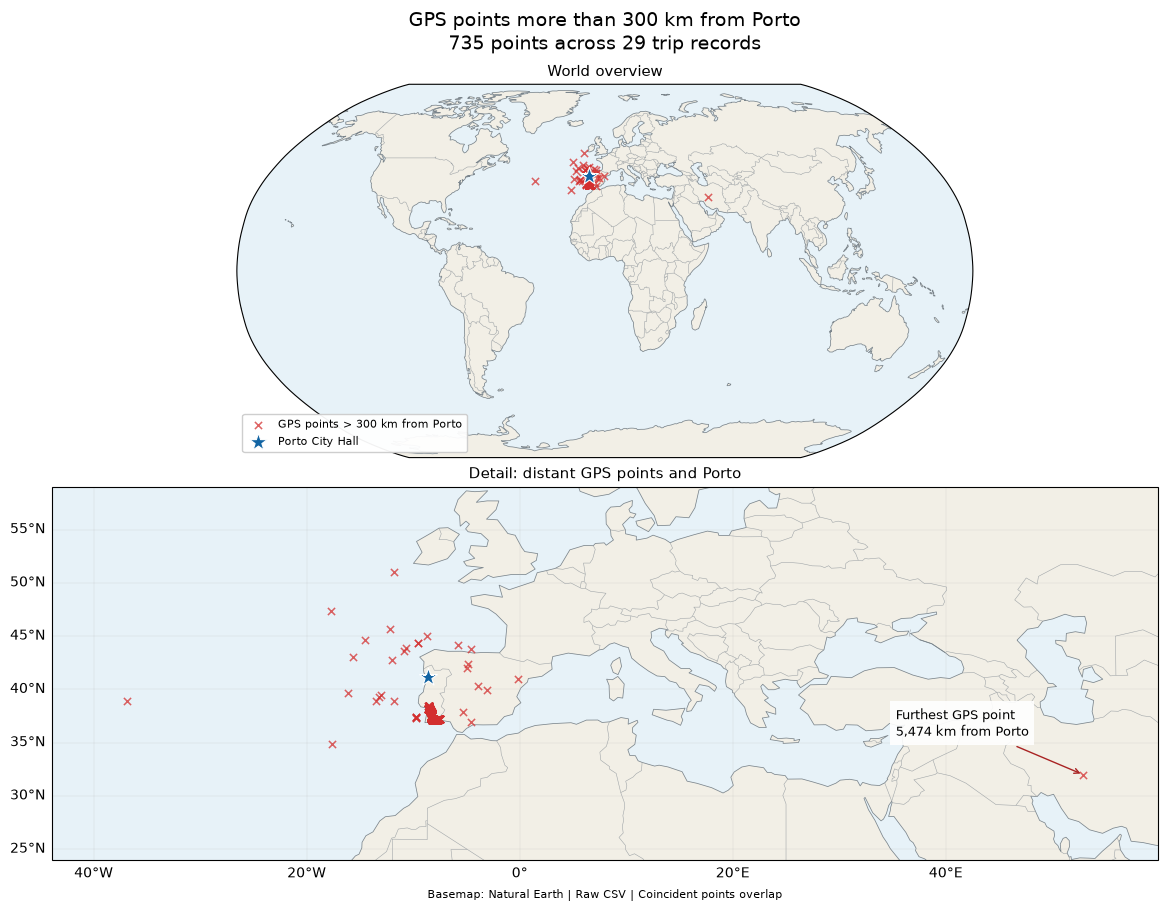

Saved map to /Users/halvardnordberg/Desktop/assignment2/eda/figures/gps_outliers_map.png


In [24]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

if far_point_df.empty:
    raise ValueError(f"No GPS points found more than {MAP_THRESHOLD_KM} km from Porto.")

geographic = ccrs.PlateCarree()
fig = plt.figure(figsize=(13, 9), layout="constrained")
world = fig.add_subplot(2, 1, 1, projection=ccrs.Robinson())
detail = fig.add_subplot(2, 1, 2, projection=geographic)
world.set_global()

lons = np.r_[far_point_df["lon"].to_numpy(), CH_LON]
lats = np.r_[far_point_df["lat"].to_numpy(), CH_LAT]
detail.set_extent(
    [max(-180, lons.min() - 7), min(180, lons.max() + 7),
     max(-85, lats.min() - 8), min(85, lats.max() + 8)],
    crs=geographic,
)

for ax in (world, detail):
    ax.set_facecolor("#e7f2f8")
    ax.add_feature(cfeature.LAND.with_scale("110m"), facecolor="#f2efe6")
    ax.coastlines(resolution="110m", linewidth=0.55, color="#7b858c")
    ax.add_feature(
        cfeature.BORDERS.with_scale("110m"), linewidth=0.4, edgecolor="#a0a5a8"
    )
    ax.scatter(
        far_point_df["lon"], far_point_df["lat"], transform=geographic,
        marker="x", s=27, linewidths=1.1, color="#d32f2f", alpha=0.75,
        zorder=4, label=f"GPS points > {MAP_THRESHOLD_KM} km from Porto",
    )
    ax.scatter(
        [CH_LON], [CH_LAT], transform=geographic, marker="*", s=180,
        color="#1264a3", edgecolors="white", linewidths=0.8,
        zorder=6, label="Porto City Hall",
    )

farthest = far_point_df.loc[far_point_df["distance_km"].idxmax()]
detail.annotate(
    f"Furthest GPS point\n{farthest['distance_km']:,.0f} km from Porto",
    (farthest["lon"], farthest["lat"]),
    xycoords=geographic._as_mpl_transform(detail), xytext=(-135, 28),
    textcoords="offset points", fontsize=9,
    bbox={"facecolor": "white", "alpha": 0.9, "edgecolor": "none"},
    arrowprops={"arrowstyle": "->", "color": "#a92323"},
)

grid = detail.gridlines(draw_labels=True, linewidth=0.35, alpha=0.35)
grid.top_labels = grid.right_labels = False
world.set_title("World overview", fontsize=11)
detail.set_title("Detail: distant GPS points and Porto", fontsize=11)
world.legend(loc="lower left", fontsize=8, framealpha=0.95)
fig.suptitle(
    f"GPS points more than {MAP_THRESHOLD_KM} km from Porto\n"
    f"{len(far_point_df):,} points across {far_point_df['source_row'].nunique():,} trip records",
    fontsize=14,
)
fig.supxlabel("Basemap: Natural Earth | Raw CSV | Coincident points overlap", fontsize=8)
map_path = FIGURES_DIR / "gps_outliers_map.png"
fig.savefig(map_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved map to {map_path}")


The trips with a point more than 300 km from City Hall, sorted by the furthest point. The
`map` column links to the location in Google Maps, which was used to see where the points lie
(Atlantic Ocean, Spain, Iran).

In [ ]:
CH_LON, CH_LAT = -8.62911, 41.15794
TOP = 10
rows = []

for i, chunk in enumerate(pd.read_csv(PATH, chunksize=CHUNKSIZE, dtype={"TRIP_ID": str},
                                      usecols=["TRIP_ID", "TAXI_ID", "CALL_TYPE", "POLYLINE"])):
    for tid, taxi, ct, poly in zip(chunk["TRIP_ID"], chunk["TAXI_ID"], chunk["CALL_TYPE"], chunk["POLYLINE"]):
        if poly_len(poly) == 0:
            continue
        pts = np.fromstring(poly.replace("[", "").replace("]", ""), sep=",").reshape(-1, 2)
        d_km = haversine_m(pts[:, 0], pts[:, 1], CH_LON, CH_LAT) / 1000
        j = int(d_km.argmax())
        if d_km[j] < 300:
            continue
        rows.append({
            "TRIP_ID": tid, "TAXI_ID": taxi, "CALL_TYPE": ct, "points": len(pts),
            "far_points": int((d_km > 300).sum()),
            "start_km_from_CH": round(float(d_km[0]), 1),
            "other_max_km": round(float(d_km[d_km <= 300].max()), 1) if (d_km <= 300).any() else None,
            "max_km_from_CH": round(float(d_km[j]), 0),
            "lon": round(float(pts[j, 0]), 5), "lat": round(float(pts[j, 1]), 5),
        })
    print(f"chunk {i} done")

far_df = pd.DataFrame(rows).sort_values("max_km_from_CH", ascending=False)
far_df["map"] = "https://www.google.com/maps?q=" + far_df["lat"].astype(str) + "," + far_df["lon"].astype(str)
print(f"Trips with a point > 300 km away: {len(far_df)}")
print(far_df.head(TOP).to_string(index=False))

chunk 0 done


chunk 1 done


chunk 2 done


chunk 3 done
Trips with a point > 300 km away: 29
            TRIP_ID  TAXI_ID CALL_TYPE  points  far_points  start_km_from_CH  other_max_km  max_km_from_CH       lon      lat                                              map
1393337802620000156 20000156         C       1           1            5473.7           NaN          5474.0  52.90080 31.99211   https://www.google.com/maps?q=31.99211,52.9008
1399451204620000018 20000018         C       1           1            2411.8           NaN          2412.0 -36.91378 38.86060  https://www.google.com/maps?q=38.8606,-36.91378
1376974718620000280 20000280         C      14           1            1125.5           6.0          1125.0 -11.82065 51.03712 https://www.google.com/maps?q=51.03712,-11.82065
1401352882620000231 20000231         B       1           1            1052.4           NaN          1052.0 -17.64295 34.88546 https://www.google.com/maps?q=34.88546,-17.64295
1385030885620000018 20000018         A       1           1            1001.

The most extreme point (5,474 km away, in Iran) belongs to a single-point trip of taxi 20000156.
To check whether it is an isolated GPS error, all trips of the same taxi within ±24 hours are
listed with their start and end distance from City Hall.

In [ ]:
TID = "1393337802620000156"
TAXI = 20000156
TS = 1393337802
rows = []
raw = None

for chunk in pd.read_csv(PATH, chunksize=CHUNKSIZE, dtype={"TRIP_ID": str}):
    sub = chunk[(chunk["TAXI_ID"] == TAXI) & (chunk["TIMESTAMP"].between(TS - 86400, TS + 86400))]
    for _, r in sub.iterrows():
        if r["TRIP_ID"] == TID:
            raw = r["POLYLINE"]
        if poly_len(r["POLYLINE"]) == 0:
            rows.append({"TRIP_ID": r["TRIP_ID"], "start_time": pd.to_datetime(r["TIMESTAMP"], unit="s"),
                         "CALL_TYPE": r["CALL_TYPE"], "points": 0, "start_km_from_CH": None, "end_km_from_CH": None})
            continue
        pts = np.fromstring(r["POLYLINE"].replace("[", "").replace("]", ""), sep=",").reshape(-1, 2)
        d = haversine_m(pts[:, 0], pts[:, 1], -8.62911, 41.15794) / 1000
        rows.append({"TRIP_ID": r["TRIP_ID"], "start_time": pd.to_datetime(r["TIMESTAMP"], unit="s"),
                     "CALL_TYPE": r["CALL_TYPE"], "points": len(pts),
                     "start_km_from_CH": round(float(d[0]), 1), "end_km_from_CH": round(float(d[-1]), 1)})

print("Raw POLYLINE of the Iran trip:", raw)
print(pd.DataFrame(rows).sort_values("start_time").to_string(index=False))

The same taxi and time window as a plot: distance from City Hall for every GPS point, on a log
scale. All points lie within a few kilometres of City Hall except the single erroneous one.

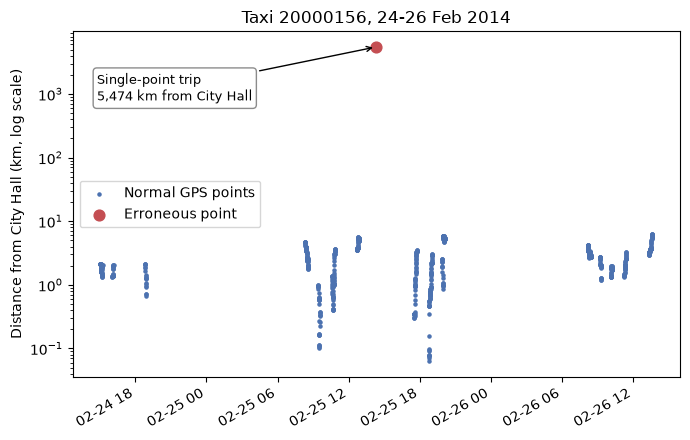

Other GPS points of taxi 20000156 in the window: 775, furthest 6.2 km from City Hall


In [ ]:
CH_LON, CH_LAT = -8.62911, 41.15794
TID, TAXI, TS = "1393337802620000156", 20000156, 1393337802

all_t, all_d, all_out = [], [], []
out_t = out_d = None

for chunk in pd.read_csv(PATH, chunksize=CHUNKSIZE, dtype={"TRIP_ID": str}):
    sub = chunk[(chunk["TAXI_ID"] == TAXI) & (chunk["TIMESTAMP"].between(TS - 86400, TS + 86400))]
    for _, r in sub.iterrows():
        if poly_len(r["POLYLINE"]) == 0:
            continue
        pts = np.fromstring(r["POLYLINE"].replace("[", "").replace("]", ""), sep=",").reshape(-1, 2)
        d = haversine_m(pts[:, 0], pts[:, 1], CH_LON, CH_LAT) / 1000
        t = pd.to_datetime(r["TIMESTAMP"] + 15 * np.arange(len(pts)), unit="s")
        is_out = r["TRIP_ID"] == TID
        all_t.append(np.asarray(t)); all_d.append(np.clip(d, 0.05, None)); all_out.append(np.full(len(pts), is_out))
        if is_out:
            out_t, out_d = t[0], float(d[0])

all_t = np.concatenate(all_t)
all_d = np.concatenate(all_d)
all_out = np.concatenate(all_out)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.scatter(all_t[~all_out], all_d[~all_out], s=5, color="#4C72B0", label="Normal GPS points")
ax.scatter(all_t[all_out], all_d[all_out], s=60, color="#C44E52", zorder=3, label="Erroneous point")
ax.set_yscale("log")
ax.set_ylabel("Distance from City Hall (km, log scale)")
ax.set_title(f"Taxi {TAXI}, 24-26 Feb 2014")
ax.annotate(f"Single-point trip\n{out_d:,.0f} km from City Hall",
            xy=(out_t, out_d), xytext=(0.04, 0.80), textcoords="axes fraction",
            arrowprops=dict(arrowstyle="->"), fontsize=9,
            bbox=dict(boxstyle="round", facecolor="white", edgecolor="gray", alpha=0.9))
ax.legend(loc="center left")
fig.autofmt_xdate()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "outlier_trip_example.png", dpi=150)
plt.show()
print(f"Other GPS points of taxi {TAXI} in the window: {(~all_out).sum():,}, "
      f"furthest {all_d[~all_out].max():.1f} km from City Hall")

#### Jumps between consecutive points
Since points are sampled every 15 seconds, the distance between two consecutive points implies
a speed. A segment implying more than 150 km/h (625 m in 15 s) is counted as a GPS jump.

In [ ]:
print(f"Jump segments (> 150 km/h): {jump_segments:,} in {jump_trips:,} trips "
      f"({jump_trips / total_rows * 100:.1f}% of all trips)")
top_taxis = sorted(jumps_by_taxi.items(), key=lambda x: -x[1])[:5]
for taxi, c in top_taxis:
    print(f"  taxi {taxi}: {c:,} jumps ({c/jump_segments*100:.1f}% of all)")
print(f"Taxis with at least one jump: {len(jumps_by_taxi)}")

Jump segments (> 150 km/h): 223,060 in 174,912 trips (10.2% of all trips)
  taxi 20000902: 5,489 jumps (2.5% of all)
  taxi 20000351: 5,244 jumps (2.4% of all)
  taxi 20000393: 2,976 jumps (1.3% of all)
  taxi 20000540: 2,612 jumps (1.2% of all)
  taxi 20000496: 2,556 jumps (1.1% of all)
Taxis with at least one jump: 439


#### Start point density
Density of the trip start locations as a 2D histogram (hexbin, log scale), zoomed in on Porto,
with City Hall marked.

Start points: 1,704,769, inside plotted area: 1,695,209 (99.44%)


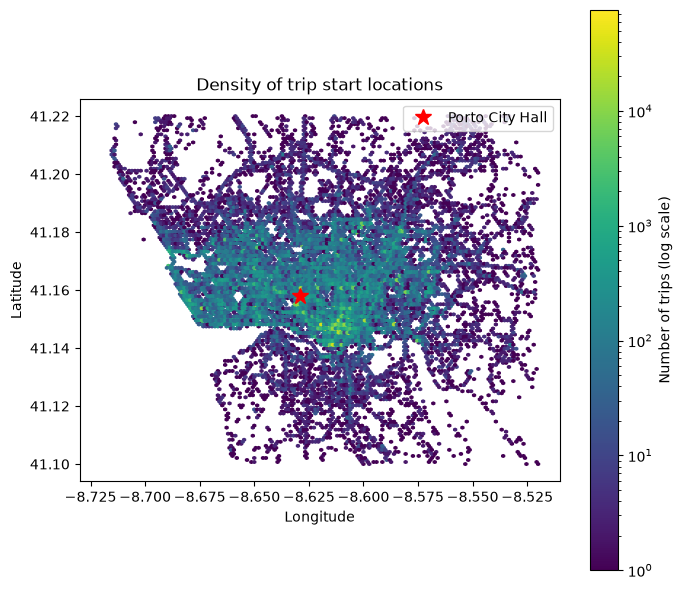

Densest hexbin cell: 75,874 trips at (-8.5853, 41.1488), +3.67 km east and -1.01 km north of City Hall


In [ ]:
# Start point density (zoomed in on Porto)
ext = (-8.72, -8.52, 41.10, 41.22)
inside = ((starts[:, 0] >= ext[0]) & (starts[:, 0] <= ext[1]) &
          (starts[:, 1] >= ext[2]) & (starts[:, 1] <= ext[3]))
print(f"Start points: {len(starts):,}, inside plotted area: {inside.sum():,} ({inside.mean()*100:.2f}%)")

fig, ax = plt.subplots(figsize=(7, 6))
hb = ax.hexbin(starts[inside, 0], starts[inside, 1], gridsize=150, extent=ext,
               bins="log", mincnt=1, cmap="viridis")
ax.plot(CH_LON, CH_LAT, "r*", markersize=12, label="Porto City Hall")
ax.set_aspect(1 / np.cos(np.radians(41.15)))
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
ax.set_title("Density of trip start locations")
fig.colorbar(hb, label="Number of trips (log scale)")
ax.legend(loc="upper right")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "start_density.png", dpi=150)
plt.show()
counts_hb = hb.get_array()
lon_d, lat_d = hb.get_offsets()[np.argmax(counts_hb)]
print(f"Densest hexbin cell: {int(counts_hb.max()):,} trips at ({lon_d:.4f}, {lat_d:.4f}), "
      f"{(lon_d - CH_LON) * 111.32 * np.cos(np.radians(CH_LAT)):+.2f} km east and "
      f"{(lat_d - CH_LAT) * 110.57:+.2f} km north of City Hall")

### Unusually long trips
Number of trips lasting at least 2, 4 and 8 hours, and the eight longest trips by number of
points. A duration of at least 2 hours, $(N-1) \times 15 \ge 7200$ s, means at least 481
points, which is the same rule as the duration outlier rule in `loader.py`.

In [ ]:
thresholds = {">= 2 h (481 pts)": 481, ">= 4 h (961 pts)": 961, ">= 8 h (1921 pts)": 1921}
long_counts = {k: 0 for k in thresholds}
candidates = []   # (N, TRIP_ID, TAXI_ID, CALL_TYPE, TIMESTAMP, POLYLINE)
total = 0

for chunk in pd.read_csv(PATH, chunksize=CHUNKSIZE, dtype={"TRIP_ID": str}):
    lens = chunk["POLYLINE"].apply(poly_len)
    total += len(chunk)
    for k, t in thresholds.items():
        long_counts[k] += int((lens >= t).sum())
    big = chunk[lens >= 1000]
    for (_, r), n in zip(big.iterrows(), lens[lens >= 1000]):
        candidates.append((int(n), r["TRIP_ID"], r["TAXI_ID"], r["CALL_TYPE"],
                           r["TIMESTAMP"], r["POLYLINE"]))

print(f"Total rows: {total:,}")
for k, v in long_counts.items():
    print(f"{k}: {v:,} trips ({v/total*100:.4f}%)")

rows = []
for n, tid, taxi, ct, ts, poly in sorted(candidates, reverse=True)[:8]:
    pts = np.fromstring(poly.replace("[", "").replace("]", ""), sep=",").reshape(-1, 2)
    steps = haversine_m(pts[:-1, 0], pts[:-1, 1], pts[1:, 0], pts[1:, 1])
    dur_s = (n - 1) * 15
    rows.append({
        "TRIP_ID": tid, "TAXI_ID": taxi, "CALL_TYPE": ct, "points": n,
        "duration_h": round(dur_s / 3600, 1),
        "distance_km": round(steps.sum() / 1000, 1),
        "avg_speed_kmh": round(steps.sum() / dur_s * 3.6, 1),
        "max_step_m": int(steps.max()),
        "lat_span_deg": round(pts[:, 1].max() - pts[:, 1].min(), 3),
    })
long_trips_df = pd.DataFrame(rows)
print(long_trips_df.to_string(index=False))

Total rows: 1,710,670
>= 2 h (481 pts): 2,267 trips (0.1325%)
>= 4 h (961 pts): 405 trips (0.0237%)
>= 8 h (1921 pts): 52 trips (0.0030%)
            TRIP_ID  TAXI_ID CALL_TYPE  points  duration_h  distance_km  avg_speed_kmh  max_step_m  lat_span_deg
1393061275620000681 20000681         C    3881        16.2        203.4           12.6         568         0.366
1400312076620000562 20000562         C    3872        16.1        156.7            9.7         475         0.403
1383293324620000520 20000520         B    3836        16.0         63.9            4.0         768         0.072
1376892235620000086 20000086         C    3590        15.0        440.9           29.5         566         1.561
1375289927620000902 20000902         C    3571        14.9         34.8            2.3         519         0.096
1379954402620000904 20000904         C    3120        13.0        295.4           22.7         833         0.114
1375981643620000520 20000520         B    2935        12.2         52.2

A closer look at the same eight trips: start and end position, straight-line distance between
start and end compared with the path length, and the largest single step between two points.

In [ ]:
inspect_rows = []
for n, tid, taxi, ct, ts, poly in sorted(candidates, reverse=True)[:8]:
    pts = np.fromstring(poly.replace("[", "").replace("]", ""), sep=",").reshape(-1, 2)
    steps = haversine_m(pts[:-1, 0], pts[:-1, 1], pts[1:, 0], pts[1:, 1])
    i = int(steps.argmax())
    inspect_rows.append({
        "TAXI_ID": taxi, "points": n,
        "start (lon,lat)": f"({pts[0,0]:.5f}, {pts[0,1]:.5f})",
        "end (lon,lat)": f"({pts[-1,0]:.5f}, {pts[-1,1]:.5f})",
        "start-end km": round(float(haversine_m(pts[0,0], pts[0,1], pts[-1,0], pts[-1,1])) / 1000, 2),
        "start-end m": int(haversine_m(pts[0,0], pts[0,1], pts[-1,0], pts[-1,1])),
        "path km": round(float(steps.sum()) / 1000, 1),
        "max step m": int(steps[i]),
        "max step km/h": round(float(steps[i]) / 15 * 3.6),
        "max step from (lon,lat)": f"({pts[i,0]:.5f}, {pts[i,1]:.5f})",
        "max step to (lon,lat)": f"({pts[i+1,0]:.5f}, {pts[i+1,1]:.5f})",
    })
print(pd.DataFrame(inspect_rows).to_string(index=False))
print(f"\nCALL_TYPE of the eight longest trips: {pd.Series([c[3] for c in sorted(candidates, reverse=True)[:8]]).value_counts().to_dict()}")

 TAXI_ID  points      start (lon,lat)        end (lon,lat)  start-end km  start-end m  path km  max step m  max step km/h max step from (lon,lat) max step to (lon,lat)
20000681    3881 (-8.58343, 41.15866) (-8.58407, 41.16325)          0.51          512    203.4         568            136    (-8.57610, 41.21497)  (-8.57479, 41.21998)
20000562    3872 (-8.61488, 41.15105) (-8.61044, 41.15345)          0.46          458    156.7         475            114    (-8.58596, 40.88785)  (-8.58947, 40.89119)
20000520    3836 (-8.62824, 41.15756) (-8.60589, 41.11404)          5.19         5187     63.9         768            184    (-8.61181, 41.14784)  (-8.62096, 41.14724)
20000086    3590 (-8.61815, 41.16756) (-8.61803, 41.16752)          0.01           10    440.9         566            136    (-8.55512, 40.83931)  (-8.55490, 40.83422)
20000902    3571 (-8.61439, 41.14108) (-8.65262, 41.17188)          4.69         4687     34.8         519            125    (-8.60226, 41.17139)  (-8.60792, 41

### Missing trajectories
The `MISSING_DATA` flag compared with the actual length of the trajectory. The flag does not
identify the trips whose trajectories are missing: none of the trips with an empty `POLYLINE`
has it set.

In [ ]:
LEN_GROUPS = ["Empty (0 points)", "1 point", "2 points", "At least 3 points"]
missing_flag = pd.DataFrame(0, index=LEN_GROUPS, columns=["trips", "MISSING_DATA true"])

for chunk in pd.read_csv(PATH, chunksize=CHUNKSIZE, usecols=["MISSING_DATA", "POLYLINE"]):
    group = chunk["POLYLINE"].apply(poly_len).clip(upper=3).map(dict(enumerate(LEN_GROUPS)))
    flagged = chunk["MISSING_DATA"].astype(str) == "True"
    missing_flag["trips"] += group.value_counts().reindex(LEN_GROUPS, fill_value=0)
    missing_flag["MISSING_DATA true"] += group[flagged].value_counts().reindex(LEN_GROUPS, fill_value=0)

print(missing_flag.to_string())

The flagged trips with at least 3 points, with the fastest segment between two consecutive
points. A segment faster than 150 km/h counts as a GPS jump, as in the spatial analysis, where
10.2 % of all trips have at least one jump.

In [ ]:
flagged_rows = []

for chunk in pd.read_csv(PATH, chunksize=CHUNKSIZE, dtype={"TRIP_ID": str},
                         usecols=["TRIP_ID", "TAXI_ID", "CALL_TYPE", "MISSING_DATA", "POLYLINE"]):
    sub = chunk[chunk["MISSING_DATA"].astype(str) == "True"]
    for tid, taxi, ct, poly in zip(sub["TRIP_ID"], sub["TAXI_ID"], sub["CALL_TYPE"], sub["POLYLINE"]):
        n = poly_len(poly)
        row = {"TRIP_ID": tid, "TAXI_ID": taxi, "CALL_TYPE": ct, "points": n, "max_step_kmh": None}
        if n >= 2:
            pts = np.fromstring(poly.replace("[", "").replace("]", ""), sep=",").reshape(-1, 2)
            steps = haversine_m(pts[:-1, 0], pts[:-1, 1], pts[1:, 0], pts[1:, 1])
            row["max_step_kmh"] = round(float(steps.max()) / 15 * 3.6)
        flagged_rows.append(row)

flagged_df = pd.DataFrame(flagged_rows)
print(flagged_df.to_string(index=False))
valid_flagged = flagged_df[flagged_df["points"] >= 3]
print(f"\nFlagged trips with >= 3 points: {len(valid_flagged)}, "
      f"with a segment > 150 km/h: {int((valid_flagged['max_step_kmh'] > 150).sum())}")

            TRIP_ID  TAXI_ID CALL_TYPE  points  max_step_kmh
1374554455620000625 20000625         B      43          85.0
1375863510620000454 20000454         B       1           NaN
1378544246620000057 20000057         B      11        2016.0
1381233613620000387 20000387         C     483       10529.0
1386346894620000904 20000904         C     285        2641.0
1387137779620000640 20000640         C      51         539.0
1388351478620000678 20000678         A      27         187.0
1390005983620000640 20000640         C      14         189.0
1396631707620000163 20000163         C       1           NaN
1399405185620000508 20000508         C      53        1242.0

Flagged trips with >= 3 points: 8, with a segment > 150 km/h: 7


<a id="section-bivariate"></a>

## 4. Bivariate analysis
All bivariate and multivariate analyses use valid trips only (at least 3 points). Time of day is
converted from Unix time (UTC) to local Porto time (Europe/Lisbon).

The next cell builds a DataFrame `df` with one row per valid trip: call type, number of points,
path distance, local start hour and duration.

In [ ]:
TZ = "Europe/Lisbon"
CT = {"A": 0, "B": 1, "C": 2}
LABELS = {0: "A (dispatch)", 1: "B (taxi stand)", 2: "C (street hail)"}

ct_parts, n_parts, d_parts, h_parts = [], [], [], []

for i, chunk in enumerate(pd.read_csv(PATH, chunksize=CHUNKSIZE, usecols=["CALL_TYPE", "TIMESTAMP", "POLYLINE"])):
    hours = pd.to_datetime(chunk["TIMESTAMP"], unit="s", utc=True).dt.tz_convert(TZ).dt.hour.to_numpy()
    ct, nn, dd, hh = [], [], [], []
    for call, h, poly in zip(chunk["CALL_TYPE"], hours, chunk["POLYLINE"]):
        if poly_len(poly) < 3:
            continue
        pts = np.fromstring(poly.replace("[", "").replace("]", ""), sep=",").reshape(-1, 2)
        ct.append(CT[call])
        nn.append(len(pts))
        dd.append(haversine_m(pts[:-1, 0], pts[:-1, 1], pts[1:, 0], pts[1:, 1]).sum() / 1000)
        hh.append(h)
    ct_parts.append(np.array(ct, dtype=np.int8))
    n_parts.append(np.array(nn, dtype=np.int32))
    d_parts.append(np.array(dd, dtype=np.float32))
    h_parts.append(np.array(hh, dtype=np.int8))
    print(f"chunk {i} done")

df = pd.DataFrame({
    "call_type": np.concatenate(ct_parts),
    "npts": np.concatenate(n_parts),
    "dist_km": np.concatenate(d_parts),
    "hour": np.concatenate(h_parts),
})
df["dur_min"] = (df["npts"] - 1) * 15 / 60
print(f"Valid trips: {len(df):,}")

### Trip duration by CALL_TYPE
Median, mean, 99th percentile and the share of trips lasting at least 2 hours per call type,
and a box plot of the duration (outliers not shown).

In [ ]:
summary = df.groupby("call_type").agg(
    trips=("dur_min", "size"),
    median_min=("dur_min", "median"),
    mean_min=("dur_min", "mean"),
    p99_min=("dur_min", lambda x: x.quantile(0.99)),
    over_2h=("dur_min", lambda x: (x >= 120).sum()),
)
summary["over_2h_pct"] = summary["over_2h"] / summary["trips"] * 100
summary.index = [LABELS[k] for k in summary.index]
print(summary.round(2).to_string())
print(f"Street hail share of trips >= 2 h: {summary.loc['C (street hail)', 'over_2h'] / summary['over_2h'].sum() * 100:.0f}% "
      f"of {int(summary['over_2h'].sum()):,}")

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.boxplot([df.loc[df["call_type"] == k, "dur_min"] for k in (0, 1, 2)], showfliers=False)
ax.set_xticks([1, 2, 3])
ax.set_xticklabels([LABELS[k] for k in (0, 1, 2)])
ax.set_ylabel("Trip duration (min)")
ax.set_title("Trip duration by CALL_TYPE (outliers not shown)")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "duration_by_calltype.png", dpi=150)
plt.show()

### Number of GPS points vs. distance
Duration follows directly from the number of points, so the relation examined is points against
distance. The cell counts the trips far from the main trend: stationary trips (at least 20 points
but less than 0.2 km) and trips with at most 10 points but more than 20 km.

Pearson r=0.657, Spearman rho=0.780
Many points (>=20) but < 0.2 km: 2,131
Few points (<=10) but > 20 km: 9


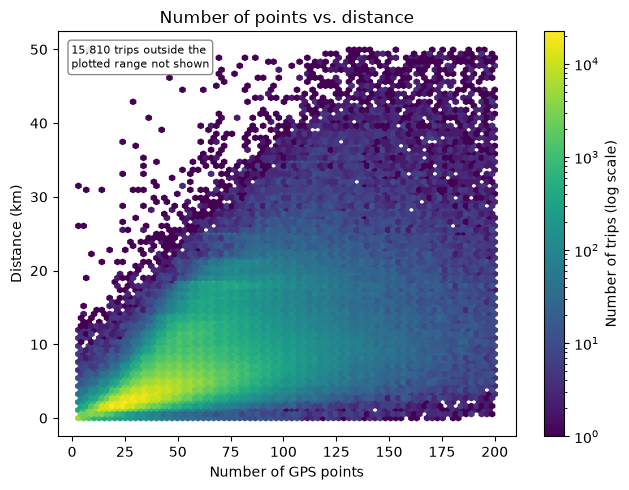

Trips outside the plotted range (> 200 points or > 50 km): 15,810
Stationary group: max average speed 2.48 km/h (upper bound 0.2 km / 285 s = 2.53 km/h)
Few points, long distance: min average speed 662 km/h (lower bound 20 km / 135 s = 533 km/h)

Densest cells (points, km, trips):
  20-25 points, 1.5-2.0 km: 35,393
  25-30 points, 2.0-2.5 km: 34,423
  20-25 points, 2.0-2.5 km: 31,147
  30-35 points, 2.5-3.0 km: 30,441
  25-30 points, 2.5-3.0 km: 28,898
  25-30 points, 1.5-2.0 km: 27,534
  30-35 points, 2.0-2.5 km: 27,335
  15-20 points, 1.5-2.0 km: 25,947
  15-20 points, 1.0-1.5 km: 25,281
  35-40 points, 2.5-3.0 km: 24,391


In [ ]:
r_p = df["npts"].corr(df["dist_km"])
r_s = df["npts"].rank().corr(df["dist_km"].rank())
stationary = int(((df["npts"] >= 20) & (df["dist_km"] < 0.2)).sum())
jumpy = int(((df["npts"] <= 10) & (df["dist_km"] > 20)).sum())
print(f"Pearson r={r_p:.3f}, Spearman rho={r_s:.3f}")
print(f"Many points (>=20) but < 0.2 km: {stationary:,}")
print(f"Few points (<=10) but > 20 km: {jumpy:,}")

m = (df["npts"] <= 200) & (df["dist_km"] <= 50)
fig, ax = plt.subplots(figsize=(6.5, 5))
hb = ax.hexbin(df.loc[m, "npts"], df.loc[m, "dist_km"], gridsize=80, bins="log", mincnt=1, cmap="viridis")
ax.set_xlabel("Number of GPS points")
ax.set_ylabel("Distance (km)")
ax.set_title("Number of points vs. distance")
ax.text(0.03, 0.97, f"{(~m).sum():,} trips outside the\nplotted range not shown",
        transform=ax.transAxes, ha="left", va="top", fontsize=8,
        bbox=dict(boxstyle="round", facecolor="white", edgecolor="gray", alpha=0.9))
fig.colorbar(hb, label="Number of trips (log scale)")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "points_vs_distance.png", dpi=150)
plt.show()
print(f"Trips outside the plotted range (> 200 points or > 50 km): {(~m).sum():,}")

speed_all = df["dist_km"] / (df["dur_min"] / 60)
stat_mask = (df["npts"] >= 20) & (df["dist_km"] < 0.2)
jump_mask = (df["npts"] <= 10) & (df["dist_km"] > 20)
print(f"Stationary group: max average speed {speed_all[stat_mask].max():.2f} km/h "
      f"(upper bound 0.2 km / {19 * 15} s = {0.2 / (19 * 15 / 3600):.2f} km/h)")
print(f"Few points, long distance: min average speed {speed_all[jump_mask].min():.0f} km/h "
      f"(lower bound 20 km / {9 * 15} s = {20 / (9 * 15 / 3600):.0f} km/h)")

# Densest area: 2D histogram with 5-point x 0.5-km cells
h2, xe, ye = np.histogram2d(df["npts"], df["dist_km"], bins=[np.arange(0, 205, 5), np.arange(0, 50.5, 0.5)])
top = np.dstack(np.unravel_index(np.argsort(h2.ravel())[::-1][:10], h2.shape))[0]
print("\nDensest cells (points, km, trips):")
for a, b in top:
    print(f"  {xe[a]:.0f}-{xe[a + 1]:.0f} points, {ye[b]:.1f}-{ye[b + 1]:.1f} km: {int(h2[a, b]):,}")

### CALL_TYPE by hour of day
Share of each call type per local hour of day.

call_type  A (dispatch)  B (taxi stand)  C (street hail)
hour                                                    
0                  18.8            47.8             33.4
1                  17.4            43.1             39.5
2                  14.0            36.9             49.1
3                  10.7            30.4             58.9
4                  11.5            26.9             61.5
5                  13.5            23.4             63.1
6                  16.1            26.4             57.5
7                  25.2            39.7             35.1
8                  29.6            49.7             20.7
9                  26.7            53.6             19.7
10                 25.6            54.5             19.9
11                 23.4            54.3             22.3
12                 22.2            55.6             22.2
13                 23.5            53.5             22.9
14                 23.6            54.2             22.2
15                 23.7        

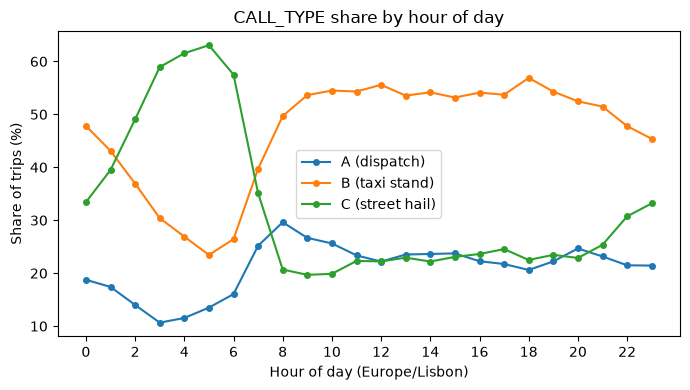


Largest call type per hour: {0: 'B', 1: 'B', 2: 'C', 3: 'C', 4: 'C', 5: 'C', 6: 'C', 7: 'B', 8: 'B', 9: 'B', 10: 'B', 11: 'B', 12: 'B', 13: 'B', 14: 'B', 15: 'B', 16: 'B', 17: 'B', 18: 'B', 19: 'B', 20: 'B', 21: 'B', 22: 'B', 23: 'B'}
Share of C among all valid trips: 29.8%
B share 09-21: 51.5-56.9%, 08-23: 45.4-56.9%


In [ ]:
share = pd.crosstab(df["hour"], df["call_type"], normalize="index") * 100
print(share.rename(columns=LABELS).round(1).to_string())

fig, ax = plt.subplots(figsize=(7, 4))
for k in (0, 1, 2):
    ax.plot(share.index, share[k], marker="o", markersize=4, label=LABELS[k])
ax.set_xticks(range(0, 24, 2))
ax.set_xlabel(f"Hour of day ({TZ})")
ax.set_ylabel("Share of trips (%)")
ax.set_title("CALL_TYPE share by hour of day")
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "calltype_by_hour.png", dpi=150)
plt.show()
print("\nLargest call type per hour:", share.idxmax(axis=1).map({0: "A", 1: "B", 2: "C"}).to_dict())
print(f"Share of C among all valid trips: {(df['call_type'] == 2).mean() * 100:.1f}%")
print(f"B share 09-21: {share.loc[9:21, 1].min():.1f}-{share.loc[9:21, 1].max():.1f}%, "
      f"08-23: {share.loc[8:23, 1].min():.1f}-{share.loc[8:23, 1].max():.1f}%")

<a id="section-multivariate"></a>

## 5. Multivariate analysis
The local day of week and the average speed are added to `df`. The weekday is read in a new pass
over the file, keeping the same filter (at least 3 points) so the rows line up with `df`.

In [ ]:
# --- Add weekday to df (same order as df: valid trips only) ---
wd_parts = []
for i, chunk in enumerate(pd.read_csv(PATH, chunksize=CHUNKSIZE, usecols=["TIMESTAMP", "POLYLINE"])):
    valid = chunk["POLYLINE"].apply(poly_len).to_numpy() >= 3
    wd = pd.to_datetime(chunk["TIMESTAMP"], unit="s", utc=True).dt.tz_convert(TZ).dt.dayofweek.to_numpy()
    wd_parts.append(wd[valid].astype(np.int8))
    print(f"chunk {i} done")
weekday = np.concatenate(wd_parts)
assert len(weekday) == len(df), (len(weekday), len(df))
df["weekday"] = weekday
df["speed_kmh"] = df["dist_km"] / (df["dur_min"] / 60)

DAYS = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

### Hour of day × day of week
Number of trips per local hour and weekday, with the busiest and quietest combinations.

Trips per weekday:
Mon    222941
Tue    228977
Wed    225596
Thu    239902
Fri    268357
Sat    251896
Sun    229097

Top 5 (weekday, hour):
weekday  hour
6        4       18289
0        9       17090
3        9       16474
6        5       16320
1        9       16236

Bottom 5 (weekday, hour):
weekday  hour
0        6       3422
2        3       2953
0        4       2928
         2       2639
         3       2176


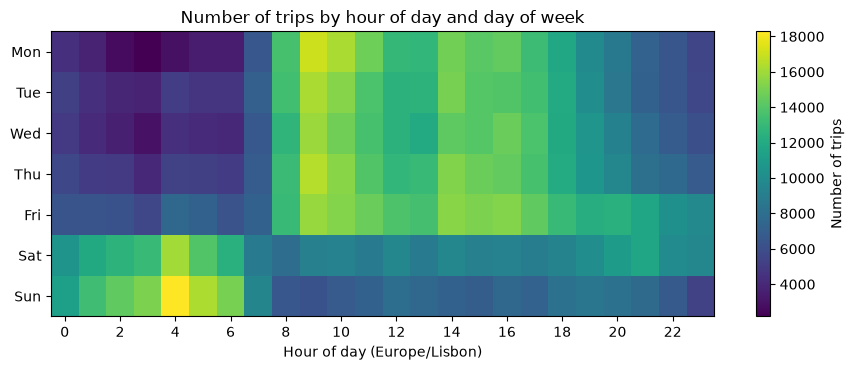

        0      1      2      3      4      5      6     7      8      9      10     11     12     13     14     15     16     17     18     19     20     21     22    23
Mon   4417   3720   2639   2176   2928   3436   3422  6542  13624  17090  16229  14702  12907  12839  14844  14136  14391  13226  11789   9873   8716   7237   6510  5548
Tue   5221   4357   3925   3724   5125   4665   4625  7098  13442  16236  15391  13736  12517  12571  14988  14044  13923  13441  12001  10076   8591   7163   6480  5637
Wed   4945   4096   3580   2953   4404   4100   4062  6625  12742  15881  14826  13610  12544  12043  14320  14014  14622  13707  11935  10582   9255   7790   6868  6092
Thu   5669   5046   4925   3983   5355   5259   5043  6891  13134  16474  15400  13894  12872  13013  15226  14660  14431  13621  12108  10616   9656   8136   7663  6827
Fri   6383   6347   6240   5597   7529   7207   6289  7187  13006  15820  15308  14633  13788  13517  15398  15115  15279  14343  13002  12215  12419 

In [ ]:
hm = pd.crosstab(df["weekday"], df["hour"]).reindex(index=range(7), columns=range(24), fill_value=0)

print("Trips per weekday:")
print(pd.Series(hm.sum(axis=1).values, index=DAYS).to_string())
cells = hm.stack().sort_values(ascending=False)
print("\nTop 5 (weekday, hour):")
print(cells.head(5).rename(index=lambda x: x).to_string())
print("\nBottom 5 (weekday, hour):")
print(cells.tail(5).to_string())

fig, ax = plt.subplots(figsize=(9, 3.8))
im = ax.imshow(hm.values, aspect="auto", cmap="viridis")
ax.set_xticks(range(0, 24, 2))
ax.set_yticks(range(7))
ax.set_yticklabels(DAYS)
ax.set_xlabel(f"Hour of day ({TZ})")
ax.set_title("Number of trips by hour of day and day of week")
fig.colorbar(im, label="Number of trips")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "heatmap_hour_weekday.png", dpi=150)
plt.show()
print(pd.DataFrame(hm.values, index=DAYS).to_string())
print("\nPeak and quietest hour per day:")
for d, row in zip(DAYS, hm.values):
    print(f"  {d}: peak {row.argmax():02d}:00 ({row.max():,}), quietest {row.argmin():02d}:00 ({row.min():,})")
print("\nMean trips per hour, night (00-05) vs. day (08-19):")
for d, row in zip(DAYS, hm.values):
    print(f"  {d}: night {row[0:6].mean():,.0f}, day {row[8:20].mean():,.0f}")

### Call type among stationary and fast trips
Duration against distance for a random sample of trips, coloured by call type. Below the plot,
the call type distribution is computed on all valid trips for two groups with implausible values:
stationary trips and trips with an average speed above 120 km/h.

In [ ]:
N_SAMPLE = 50_000
s = df.sample(N_SAMPLE, random_state=0)
s = s[(s["dur_min"] <= 60) & (s["dist_km"] <= 40)]
colors = {0: "#4C72B0", 1: "#DD8452", 2: "#55A868"}

fig, ax = plt.subplots(figsize=(6.5, 5))
for k in (0, 1, 2):
    m = s["call_type"] == k
    ax.scatter(s.loc[m, "dur_min"], s.loc[m, "dist_km"], s=3, alpha=0.25, color=colors[k], label=LABELS[k])
ax.set_xlabel("Duration (min)")
ax.set_ylabel("Distance (km)")
ax.set_title(f"Duration vs. distance (random sample of {N_SAMPLE:,} trips)")
ax.legend(markerscale=5, loc="upper left")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "scatter_multi.png", dpi=150)
plt.show()

# Call type distribution among implausible trips (on the whole df, not just the sample)
overall = df["call_type"].value_counts(normalize=True).sort_index() * 100
groups = {
    "All valid trips": pd.Series(True, index=df.index),
    "Stationary (>=20 pts, <0.2 km)": (df["npts"] >= 20) & (df["dist_km"] < 0.2),
    "Speed > 120 km/h": df["speed_kmh"] > 120,
}
out = {}
for name, mask in groups.items():
    out[name] = df.loc[mask, "call_type"].value_counts(normalize=True).sort_index() * 100
    out[name].loc["n"] = int(mask.sum())
print(pd.DataFrame(out).rename(index={0: "A", 1: "B", 2: "C"}).round(1).to_string())

### Correlation between numeric attributes
Spearman correlation (Pearson correlation of the ranks), which measures how consistently one
variable increases with another without assuming a straight line. This suits the skewed
distributions here. The number of points and the duration are identical by construction.

In [ ]:
cols = ["npts", "dur_min", "dist_km", "speed_kmh", "hour"]
names = ["num_points", "duration", "distance", "avg speed", "start hour"]
corr = df[cols].rank().corr()
print(corr.round(3).to_string())

fig, ax = plt.subplots(figsize=(5.5, 4.8))
im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(cols))); ax.set_xticklabels(names, rotation=45, ha="right")
ax.set_yticks(range(len(cols))); ax.set_yticklabels(names)
for a in range(len(cols)):
    for b in range(len(cols)):
        ax.text(b, a, f"{corr.values[a, b]:.2f}", ha="center", va="center", fontsize=9)
ax.set_title("Spearman correlation")
fig.colorbar(im)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "corr_matrix.png", dpi=150)
plt.show()

<a id="section-outliers"></a>

## 6. Outlier detection and data cleaning
Based on the analyses above, a trip is flagged as an outlier (`is_outlier`) if it breaks at least
one of these rules:

| Rule | Section |
|---|---|
| Fewer than 3 points (invalid trip, from the assignment) | 3, Very short trips |
| Duration of at least 2 hours | 3, Unusually long trips |
| Average speed above 120 km/h | 3, Trip distance and average speed |
| Stationary: at least 20 points and a distance below 0.2 km | 4, Number of GPS points vs. distance |
| A point more than 300 km from Porto City Hall | 3, Spatial analysis |

The rules are applied when the data is inserted into MySQL (`_is_outlier_trip` in `loader.py`).
The same step removes the exact duplicate rows found in section 2, drops the constant `DAY_TYPE`
column, converts `TIMESTAMP` to local Porto time and parses `POLYLINE` into individual GPS
points. Flagged trips are kept in the database.

The next cell applies the same rules here, after removing the exact duplicates in the same way as
`loader.py` (all nine columns compared as raw text), and counts the trips per rule and in total.
Duration, distance and speed are only evaluated for trips with at least 3 points, as in the EDA.
Trips with fewer points are already flagged by the first rule.

In [ ]:
RULES = ["Fewer than 3 points", "Duration >= 2 h", "Average speed > 120 km/h",
         "Stationary (>= 20 points, < 0.2 km)", "Point > 300 km from City Hall"]
rule_counts = dict.fromkeys(RULES, 0)
seen_dup_rows = set()
rows_kept = duplicates_removed = flagged_total = rules_broken_total = missing_kept = 0

for chunk in pd.read_csv(PATH, chunksize=CHUNKSIZE, dtype=str, keep_default_na=False):
    for row in chunk.itertuples(index=False):
        if row.TRIP_ID in dup_ids:
            key = tuple(row)
            if key in seen_dup_rows:
                duplicates_removed += 1
                continue
            seen_dup_rows.add(key)
        rows_kept += 1
        missing_kept += row.MISSING_DATA == "True"

        n = poly_len(row.POLYLINE)
        broken = []
        if n < 3:
            broken.append("Fewer than 3 points")
        if n > 0:
            pts = np.fromstring(row.POLYLINE.replace("[", "").replace("]", ""), sep=",").reshape(-1, 2)
            if (haversine_m(pts[:, 0], pts[:, 1], CH_LON, CH_LAT) > 300_000).any():
                broken.append("Point > 300 km from City Hall")
            if n >= 3:
                dist_m = haversine_m(pts[:-1, 0], pts[:-1, 1], pts[1:, 0], pts[1:, 1]).sum()
                dur_s = (n - 1) * 15
                if dur_s >= 2 * 60 * 60:
                    broken.append("Duration >= 2 h")
                if dist_m / dur_s * 3.6 > 120:
                    broken.append("Average speed > 120 km/h")
                if n >= 20 and dist_m < 200:
                    broken.append("Stationary (>= 20 points, < 0.2 km)")
        for r in broken:
            rule_counts[r] += 1
        rules_broken_total += len(broken)
        flagged_total += bool(broken)

print(f"Rows in the raw data:              {rows_kept + duplicates_removed:,}")
print(f"Exact duplicates removed:          {duplicates_removed}")
print(f"Rows after removing duplicates:    {rows_kept:,}")
print(f"MISSING_DATA = True after removal: {missing_kept}\n")
for r in RULES:
    print(f"{r:<38}{rule_counts[r]:>8,}")
print(f"{'Sum of the rule counts':<38}{rules_broken_total:>8,}")
print(f"{'Distinct trips flagged as outliers':<38}{flagged_total:>8,}")
print(f"{'Counted by more than one rule':<38}{rules_broken_total - flagged_total:>8,}")
print(f"{'Not flagged':<38}{rows_kept - flagged_total:>8,}")

Rows in the raw data:              1,710,670
Exact duplicates removed:          3
Rows after removing duplicates:    1,710,667
MISSING_DATA = True after removal: 10

Fewer than 3 points                     43,902
Duration >= 2 h                          2,267
Average speed > 120 km/h                 2,127
Stationary (>= 20 points, < 0.2 km)      2,131
Point > 300 km from City Hall               29
Sum of the rule counts                  50,456
Distinct trips flagged as outliers      50,405
Counted by more than one rule               51
Not flagged                           1,660,262
